# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

In [1]:
# imports
import pickle
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import warnings
from toeplitzlda.classification import ToeplitzLDA

# utils functions
from utils.preprocessing import load_session_chached, merge_sessions
from utils.online_simulation import online_simulation
from utils.feature_extraction import load_features_chached
from utils.run_patient import run_patient_online_sessions

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



In [2]:
import line_profiler
%load_ext line_profiler

def my_function(x):
    e = 0
    for i in range(x):
        e+=i

# Example:
%lprun -f my_function my_function(500)

Timer unit: 1e-07 s

Total time: 0.0003431 s
File: C:\Users\Soz\AppData\Local\Temp\ipykernel_45256\559752206.py
Function: my_function at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           def my_function(x):
     5         1          7.0      7.0      0.2      e = 0
     6       501       1731.0      3.5     50.5      for i in range(x):
     7       500       1693.0      3.4     49.3          e+=i

In [ ]:

# features_online = load_features_chached(r"B:\_anonymized_data_P01a_P1_S4_anonymized.pkl")
# # for i in range(3,18):
# #     features = load_features_chached(f"B:\_anonymized_data_P01a_P1_S{i}_anonymized.pkl")

# #for i in range(3,14):
# #    features = load_features_chached(f"B:\_anonymized_data_P02a_P1_S{i}_anonymized.pkl")

# features_train = load_features_chached(r"B:\_anonymized_data_P01a_P1_S3_anonymized.pkl")

# from pathlib import Path
# import re

# def get_help_path_from_pickle_path(pickle_path):
#     """
#     Convert a flattened pickle filename like:
#         B:\_anonymized_data_P01a_P1_S1_anonymized.pkl
#     to the original folder-style path like:
#         B:\anonymized_data\P01a\P1_S1\anonymized
#     """
#     path = Path(pickle_path)
#     fname = path.name

#     match = re.match(r"_anonymized_data_(P\d+a)_(P\d+_S\d+)_anonymized\.pkl", fname)
#     if not match:
#         raise ValueError(f"Could not parse patient/session info from: {fname}")

#     part1 = match.group(1)  # e.g. P01a
#     part2 = match.group(2)  # e.g. P1_S1

#     help_path = path.parent / "anonymized_data" / part1 / part2 / "anonymized"
#     return str(help_path)
# from pathlib import Path
# import re

# import os

# def parse_pickle_path(pickle_path):
#     # Extract the full filename without directory
#     filename = os.path.basename(pickle_path)
    
#     # Regex to extract patient/session info
#     match = re.match(r'_anonymized_data_(P\d{2}a)_P(\d+)_S(\d+)_anonymized(.*)\.pkl', filename)
#     if not match:
#         raise ValueError(f"Invalid filename format: {filename}")
    
#     project, patient, session, suffix = match.groups()

#     # Construct help_path
#     help_path = os.path.join(
#         "B:/", "anonymized_data", project, f"P{patient}_S{session}", "anonymized"
#     )

#     # Extract optional selection and discard_channels from suffix
#     selection = None
#     discard_channels = False

#     if "_dc" in suffix:
#         discard_channels = True
#         suffix = suffix.replace("_dc", "")  # Remove _dc so it doesn't pollute selection

#     # Now match selection without _dc
#     sel_match = re.search(r'(6D_\w+)', suffix)
#     if sel_match:
#         selection = sel_match.group(1)

#     return help_path, selection, discard_channels

# import glob
# import os
# from utils.feature_extraction import load_or_extract_markers

# # Define the folder containing the data
# data_dir = r"B:\\"  # Ensure it ends with a backslash or double backslash

# # Use glob to find all .pkl files that match your pattern
# file_pattern = os.path.join(data_dir, "_anonymized_data*.pkl")
# all_pickle_files = glob.glob(file_pattern)

# print(f"Found {len(all_pickle_files)} .pkl files.")

# # Loop through all files and run your function
# for pickle_path in all_pickle_files:
#     print(f"\nProcessing pickle path: {pickle_path}")
#     #"B:\anonymized_data\P01a\P1_S1\anonymized"
#     help_path, selection, discard_channels = parse_pickle_path(pickle_path=pickle_path)
#     print("help_path:",help_path)  # B:\anonymized_data\P01a\P1_S1\anonymized
#     print("selection:",selection)  # 6D_long_350
#     print("dc:",discard_channels)  # True
#     online_trials = load_session_chached((help_path),selection=selection, discard_channels=discard_channels).get('trials')
#     try:
#         markers_info = load_or_extract_markers(pickle_path, online_trials)
#     except Exception as e:
#         print(f"Failed to process {pickle_path}: {e}")





In [ ]:
# features_s1 =load_features_chached(r"B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl")
# print(features_s1.keys())

# features_s2 =load_features_chached(r"B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl")
# print(features_s2.keys())

# features_merged = merge_features(features_s1, features_s2)


In [ ]:
# Run Transfer on all
from utils.db import patients_db

print(patients_db)
for id in patients_db:
    if id==8:
        info = patients_db.get(id)
        patient = info.get('patient_nr')
        last_session = info.get('last_session')
        calibration_selection = info.get('selection')

        print("patient: ", patient)
        print("last session", last_session)
        print("calibration_selection", calibration_selection)

        performances = run_patient_online_sessions(patient, last_session, calibration_selection)
        with open(f"p{patient}_performances_v1.pkl", 'wb') as f: 
            pickle.dump(performances, f)

In [ ]:
# Run static on all

from utils.static_protocol import static_protocol
from utils.run_patient import run_patient_online_sessions_static

print(static_protocol)
for id in static_protocol:
    info = static_protocol.get(id)
    patient = info.get('patient_nr')
    last_session = info.get('last_session')
    calibration_selection = info.get('selection')
    changing_conditions = info.get('changing_condition')
    if changing_conditions:
        starter_conditions = info.get('changing_starter_sessions')
    else:
        starter_conditions = None
        
    print("patient: ", patient)
    print("last session: ", last_session)
    print("calibration_selection: ", calibration_selection)
    print("changing conditions: ", changing_conditions)

    performances = run_patient_online_sessions_static(patient, last_session, calibration_selection, starter_conditions)
    with open(f"p{patient}_performances_static_v1.pkl", 'wb') as f: 
        pickle.dump(performances, f)

In [3]:
# Code to concatenate all trails of patient 9 (pilot)
from utils.feature_extraction import merge_features

patient_string = "09"
patient = 9
last_session = 18
calibration_selection = "6D_long_350"
calibration_selection_dc =  f"{calibration_selection}_dc"


data_path_s1 = f"B:/anonymized_data/P{patient_string}a/P{patient}_S1/anonymized"
data_path_s2 = f"B:/anonymized_data/P{patient_string}a/P{patient}_S2/anonymized"
data_s1 = load_session_chached(data_path_s1, selection = calibration_selection, discard_channels=True)
data_s2 = load_session_chached(data_path_s2, selection = calibration_selection, discard_channels=True)
data_train = merge_sessions(data_s1, data_s2)
data_merged = data_train

# features_s1 = load_features_chached(f"B:_anonymized_data_P{patient_string}a_P{patient}_S1_anonymized{calibration_selection_dc}.pkl")
# features_s2 = load_features_chached(f"B:_anonymized_data_P{patient_string}a_P{patient}_S2_anonymized{calibration_selection_dc}.pkl")
# features_train = merge_features(features_s1, features_s2)
# features_merged = features_train

for i in range(3,last_session):
    data_train = data_merged
    #features_train = features_merged
    data_next =load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S{i}/anonymized")
    #features_next = load_features_chached(f"B:_anonymized_data_P{patient_string}a_P{patient}_S{i}_anonymized.pkl")
    data_merged = merge_sessions(data_train, data_next)
    #features_merged = merge_features(features_train, features_next)

del data_train
del data_s1
del data_s2
del data_path_s1
del data_path_s2
del data_next
del calibration_selection
del calibration_selection_dc
del patient
del last_session
del patient_string    


Loading file:  B:_anonymized_data_P09a_P9_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P09a_P9_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P09a_P9_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P09a_P9_S2_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P09a_P9_S3_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S3_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P09a_P9_S3_anonymized.pkl
Loading file:  B:_anonymized_data_P09a_P9_S4_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S4_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P09a_P9_S4_anonymized.pkl
Loading file:  B:_anonymized_data_P09a_P9_S5_anonymized


In [4]:
print("Data keys: ",data_merged.keys())
# for f in data_merged.get('filenames'):
#     print(f)
#print(data_merged.get('preprocessing'))
# print(f"Trials total: {len(data_merged.get('trials'))}")
# print(f"Iterations total: {len(data_merged.get('iterations'))}")
# print(f"Epochs total: {len(data_merged.get('epochs'))}")
# print(f"Preprocessing: {(data_merged.get('preprocessing'))}")
# print(f"Timestamp: {(data_merged.get('timestamp'))}")
# print(f"Loaded filenames: ")
# for f in data_merged.get('filenames'):
#     print(f)

print((data_merged.get('epochs')[:6]))
print((data_merged.get('iterations')[0]))
print((data_merged.get('trials')[0][0]))



Data keys:  dict_keys(['trials', 'iterations', 'epochs', 'filenames', 'preprocessing', 'timestamp'])
<EpochsArray | 6 events (all good), -0.2 – 1 s (baseline off), ~229 KiB, data loaded,
 'Word_6/Target': 1
 'Word_1/NonTarget': 1
 'Word_2/NonTarget': 1
 'Word_3/NonTarget': 1
 'Word_4/NonTarget': 1
 'Word_5/NonTarget': 1>
<EpochsArray | 6 events (all good), -0.2 – 1 s (baseline off), ~229 KiB, data loaded,
 'Word_6/Target': 1
 'Word_1/NonTarget': 1
 'Word_2/NonTarget': 1
 'Word_3/NonTarget': 1
 'Word_4/NonTarget': 1
 'Word_5/NonTarget': 1>
<EpochsArray | 6 events (all good), -0.2 – 1 s (baseline off), ~229 KiB, data loaded,
 'Word_6/Target': 1
 'Word_1/NonTarget': 1
 'Word_2/NonTarget': 1
 'Word_3/NonTarget': 1
 'Word_4/NonTarget': 1
 'Word_5/NonTarget': 1>


In [5]:
from sklearn.model_selection import cross_val_score
from utils.offline_evaluation import compute_auc_with_cv
from utils.feature_extraction import epoch_vectorizer_channelprime
from sklearn.pipeline import make_pipeline

def compute_cv_auc_pilot(trials, start, stop, ival_bounds, cv_folds, show_mean = True, show_folds = False, title_text=""):
    if stop is None:
        stop = len(trials)
    raw_calibration_trials = trials[start:stop]
    X,y = epoch_vectorizer_channelprime(raw_calibration_trials=raw_calibration_trials, ival_bounds=ival_bounds)

    ### Evaluation --------------------------------------------------------------------

    # print(f"AUC scores computed using a {cv_folds}-fold cross-validation - "+title_text)

    # ### SLDA
    # clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    # auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    # if show_folds:
    #     print("AUC score of sLDA, all {} folds: {}".format(cv_folds, auc_slda))
    # if show_mean:     
    #     print("Mean AUC score of sLDA: \t", auc_slda.mean())

    ### BT-LDA
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    # if show_folds:
    #     print("AUC score of BT-LDA, all {} folds: {}".format(cv_folds, auc_btlda))
    # if show_mean:    
    #     print("Mean AUC score of BT-LDA: \t", auc_btlda.mean())

    return auc_btlda.mean()

# dummydata = data_merged.get('trials')[350:400]

# scores = compute_auc_with_cv(dummydata, 0, None, np.arange(0.1,0.51,0.05),4,True,False,"idk")
# print(scores)
# scores = compute_cv_auc_pilot(dummydata, 0, None, np.arange(0.1,0.51,0.05), 4, True, False, "idk")
# print(type(scores))
# print(scores)

# def compute_auc_cv(trials, )
# calibration_labels = [(1 if event > 107 else 0) for trial in raw_calibration_trials for iteration in trial for event in iteration.events[:,2]] 
# calibration_labels = np.array(calibration_labels) # contains only 0's and 1's. # shape (samples,) e.g. (1038,)

In [ ]:

    # # TO DO: add as input parameters instead of relying on the kernel
    # session_list = [session for session in all_data.keys()]
    # #condition_list = condition_list
    # #all_data = all_data

    # n_epochs = 1800 # TO DO: make it not hard coded 
    # sizes = sizes

    # # store the scores per dataset size in a matrix for each classifier
    # #scores_wo = np.zeros((len(session_list), len(condition_list), sizes.size))  # lda
    # scores_w = np.zeros((len(session_list), len(condition_list), sizes.size))   # slda
    # scores_bt = np.zeros((len(session_list), len(condition_list), sizes.size))  # btlda

    # # added to keep track of the repetitions per dataset size 
    # # the values differ per size, depending on how often the size fits in the full dataset
    # repeats = np.array([])

    # for s_i, session in enumerate(session_list):
    #     for c_i, condition in enumerate(condition_list):
            
    #         # Extract features (channel-prime)
    #         epo = all_data[session][condition]
    #         A = get_jumping_means(epo, clf_ival_boundaries).squeeze()
    #         A_new = make_channels_first(A)
    #         X = A_new.reshape((-1, n_features))
    #         y = epo.events[:,2]

    #         # Initialize the classifiers lda, slda, btlda
    #         # lda_wo = LDA(solver='lsqr')
    #         lda_w = LDA(solver='lsqr', shrinkage='auto')
    #         lda_bt = ToeplitzLDA(n_channels=n_channels)
            
    #         # For every defined dataset size
    #         for i, size in enumerate(sizes):

    #             # Repeating: per size it computes the mean auc score (over 5 folds cv) many times, everytime for a new interval 
    #             # between each interval, steps are taken of given step size.
    #             # Example: dataset size 50, step size 10 gives the intervals: [50,100], [60,110], [70,120], ..., [1750,1800]

    #             # to keep track of all calculated auc scores per interval (= per repititon) 
    #             # m1 = np.array([]) # lda 
    #             m2 = np.array([]) # slda
    #             m3 = np.array([]) # btlda

    #             if tracker:
    #                 print("S{}, C{}, Computing average auc score for size {}".format(s_i,c_i,size))

    #             # Repeating: loop over all possible intervals starting from the size itself until 1800, taking steps of the given step size
    #             for j in range(size,n_epochs-size,step_size):

    #                 if tracker:
    #                     print("\t interval: [{},{}]".format(j, j+size))

    #                 # m1 = np.append(m1,cross_val_score(lda_wo, X[j:j+size, :], y[j:j+size], cv=5, scoring='roc_auc').mean())
    #                 m2 = np.append(m2,cross_val_score(lda_w, X[j:j+size, :], y[j:j+size], cv=5, scoring='roc_auc').mean())
    #                 m3 = np.append(m3,cross_val_score(lda_bt, X[j:j+size, :], y[j:j+size], cv=5, scoring='roc_auc').mean())

    #             # average the auc score over all repetitions to obtain the value for a certain dataset size
    #             # scores_wo[s_i, c_i, i] = m1.mean() # lda 
    #             scores_w[s_i, c_i, i] = m2.mean()  # slda
    #             scores_bt[s_i, c_i, i] = m3.mean() # btlda

    #             # Keeping track of the number of repetitions per dataset size
    #             # keep track only for session 1, condition 1. Otherwise we have 6 times the same repeats array
    #             if s_i == 1 and c_i == 1: 
    #                 repeats = np.append(repeats,len(m2))
                    
    #             if tracker:
    #                 #print("avg auc scores: lda {} - slda {} - btlda {}".format(m1.mean(), m2.mean(), m3.mean()))
    #                 print(f"avg auc scores: slda {m2.mean()} - btlda {m3.mean()}")

    # #return scores_wo, scores_w, scores_bt, repeats    
    # return scores_w, scores_bt, repeats        
    


In [88]:
from sklearn.model_selection import cross_val_score

def cv_auc_repeating_sizes(data, sizes = np.arange(90,900,90), step_size = 90, tracker=False, resampling=False):
    """ 
    This function computes the AUC scores for the classifier BTLDA over a set of different dataset sizes.

    The function keeps track of the AUC scores for different dataset sizes. For each dataset size, multiple samples (repetitions) are taken from the dataset, with a distance step_size between samples. Per dataset size, the number of taken samples is stored in repeats. The average over all samples is computed and its result is the final AUC score for that dataset size.
    """

    all_trials = data.get('trials')
    #n_epochs = int(len(data.get('epochs'))/4) # for splitting it into 4 parts
    n_epochs = len(data.get('epochs'))
    scores_bt = np.zeros(sizes.size)  # btlda

    print(f"Number of sizes: {(scores_bt).shape[0]}")
    print(f"Sizes: {sizes}")
    print(f"Step size: {step_size}")
    print(f"Trials total: {len(all_trials)}")
    print(f"Epochs total: {n_epochs}")
    start = 0
    #end = 60696
    #cond = "6D"
    #start = 60696
    end = n_epochs
    #cond = "HP"

    print(f"Using only epochs {start}-{end} (all sessions, - all conditions)")
    #print(f"Using the first epochs until 53226")

    # added to keep track of the repetitions per dataset size 
    # the values differ per size, depending on how often the size fits in the full dataset
    repeats = np.array([])

    # Extract features (channel-prime)
    ival_bounds = np.arange(0.1,0.51,0.05)
    print(f"Time intervals: {ival_bounds}")
    X,y = epoch_vectorizer_channelprime(all_trials, ival_bounds=ival_bounds)

    # Initialize the classifier
    nch = (all_trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )

    for i, size in enumerate(sizes):
        size_scores = np.array([]) # btlda
        if resampling is False:
            step_size = size

        if tracker:
            print(f"Computing average auc score for size {size} (out of {(scores_bt).shape[0]})")

        # Repeating: loop over all possible intervals starting from the size itself, taking steps of the given step size
        for j in range(start, end-size+1,step_size):
            if tracker:
                print(f"\t interval: [{j},{j+size}] / {n_epochs}")

            size_scores = np.append(size_scores,cross_val_score(clf_btlda, X[j:j+size, :], y[j:j+size], cv=4, scoring='roc_auc').mean())

        # average the auc score over all repetitions to obtain the value for a certain dataset size
        print(size_scores)
        scores_bt[i] = size_scores.mean() # btlda

        # Keeping track of the number of repetitions per dataset size
        # keep track only for session 1, condition 1. Otherwise we have 6 times the same repeats array
        repeats = np.append(repeats,len(size_scores))
            
        if tracker:
            #print("avg auc scores: lda {} - slda {} - btlda {}".format(m1.mean(), m2.mean(), m3.mean()))
            print(f"avg auc score: btlda {size_scores.mean()}")

    return scores_bt, repeats        

from sklearn.model_selection import cross_val_score

def cv_auc_single_sizes(data, sizes = np.arange(90,900,90), tracker=False):

    all_trials = data.get('trials')
    n_epochs = int(len(data.get('epochs'))/4)
    scores_bt = np.zeros(sizes.size)  # btlda

    print(f"Number of sizes: {(scores_bt).shape[0]}")
    print(f"Sizes: {sizes}")
    print(f"Trials total: {len(all_trials)}")
    print(f"Epochs total: {n_epochs}")

    # added to keep track of the repetitions per dataset size 
    # the values differ per size, depending on how often the size fits in the full dataset
    repeats = np.array([])

    # Extract features (channel-prime)
    ival_bounds = np.arange(0.1,0.51,0.05)
    print(f"Time intervals: {ival_bounds}")
    X,y = epoch_vectorizer_channelprime(all_trials, ival_bounds=ival_bounds)

    # Initialize the classifier
    nch = (all_trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )


    for i, size in enumerate(sizes):

        if tracker:
            print(f"Computing average auc score for size {size}")

        print(f"\t interval: [{900},{900+size}] / {n_epochs}")

            #print(y[0:j+size])
        size_scores = (cross_val_score(clf_btlda, X[900:900+size, :], y[900:900+size], cv=4, scoring='roc_auc').mean())

        # average the auc score over all repetitions to obtain the value for a certain dataset size
        scores_bt[i] = size_scores # btlda

        # Keeping track of the number of repetitions per dataset size
        # keep track only for session 1, condition 1. Otherwise we have 6 times the same repeats array
        #repeats = np.append(repeats,len(size_scores))
            
        if tracker:
            #print("avg auc scores: lda {} - slda {} - btlda {}".format(m1.mean(), m2.mean(), m3.mean()))
            print(f"avg auc score: btlda {size_scores}")

    return scores_bt       




In [67]:
small_sizes = np.arange(90,1290,90)
print(small_sizes)
big_sizes = np.arange(1200,15000,600)


[  90  180  270  360  450  540  630  720  810  900  990 1080 1170 1260]


In [89]:
small_sizes = np.arange(90,1290,90)
step_size = 90
small_sizes_scores_all = cv_auc_repeating_sizes(data_merged, sizes=small_sizes, step_size=step_size, tracker=True, resampling=False)
#single_sizes_scores = cv_auc_single_sizes(data_merged, sizes=sizes, tracker=True)

# first quarter is taking intervals in range or j in range(0,int(n_epochs/4)-size+1,step_size): 
# q1: 0-23760 epochs (the last interval indeed takes up until epoh 23760)
# q2: 23760-47520
# q3: 47520-71280
# q4: 71280-95040
with open(f"NEW_small_sizes_scores_all.pkl", 'wb') as f: 
    pickle.dump(small_sizes_scores_all, f)

Number of sizes: 14
Sizes: [  90  180  270  360  450  540  630  720  810  900  990 1080 1170 1260]
Step size: 90
Trials total: 1302
Epochs total: 95040
Using only epochs 0-95040 (all sessions, - all conditions)
Time intervals: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
Computing average auc score for size 90 (out of 14)
	 interval: [0,90] / 95040
	 interval: [90,180] / 95040
	 interval: [180,270] / 95040
	 interval: [270,360] / 95040
	 interval: [360,450] / 95040
	 interval: [450,540] / 95040
	 interval: [540,630] / 95040
	 interval: [630,720] / 95040
	 interval: [720,810] / 95040
	 interval: [810,900] / 95040
	 interval: [900,990] / 95040
	 interval: [990,1080] / 95040
	 interval: [1080,1170] / 95040
	 interval: [1170,1260] / 95040
	 interval: [1260,1350] / 95040
	 interval: [1350,1440] / 95040
	 interval: [1440,1530] / 95040
	 interval: [1530,1620] / 95040
	 interval: [1620,1710] / 95040
	 interval: [1710,1800] / 95040
	 interval: [1800,1890] / 95040
	 interval: [1890,1980] / 950

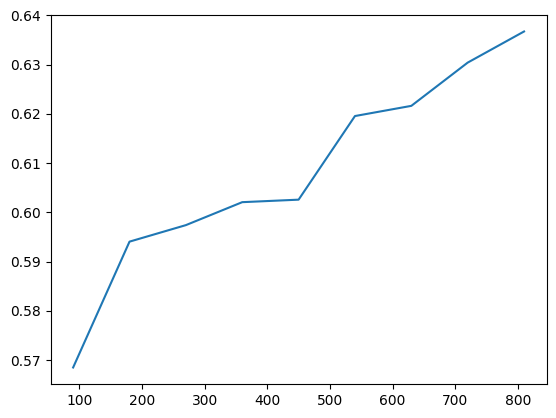

In [36]:
plt.figure()
plt.plot(sizes, sizes_scores[0])
plt.show()

In [100]:
combined_sizes_all = np.append(small_sizes_scores_6D[0],sizes_scores_6D[0])

In [97]:
print(sizes_scores[0].shape)

(23,)


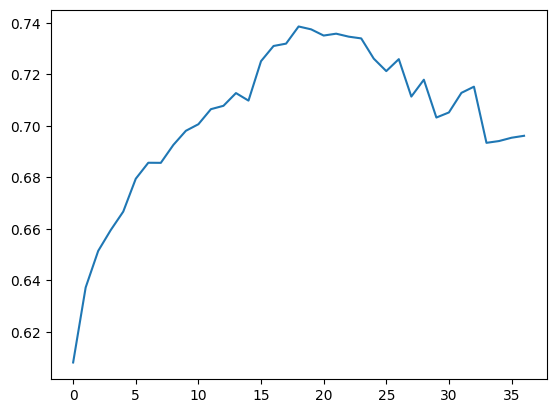

In [101]:
plt.figure()
plt.plot(combined_sizes_all)
plt.show()

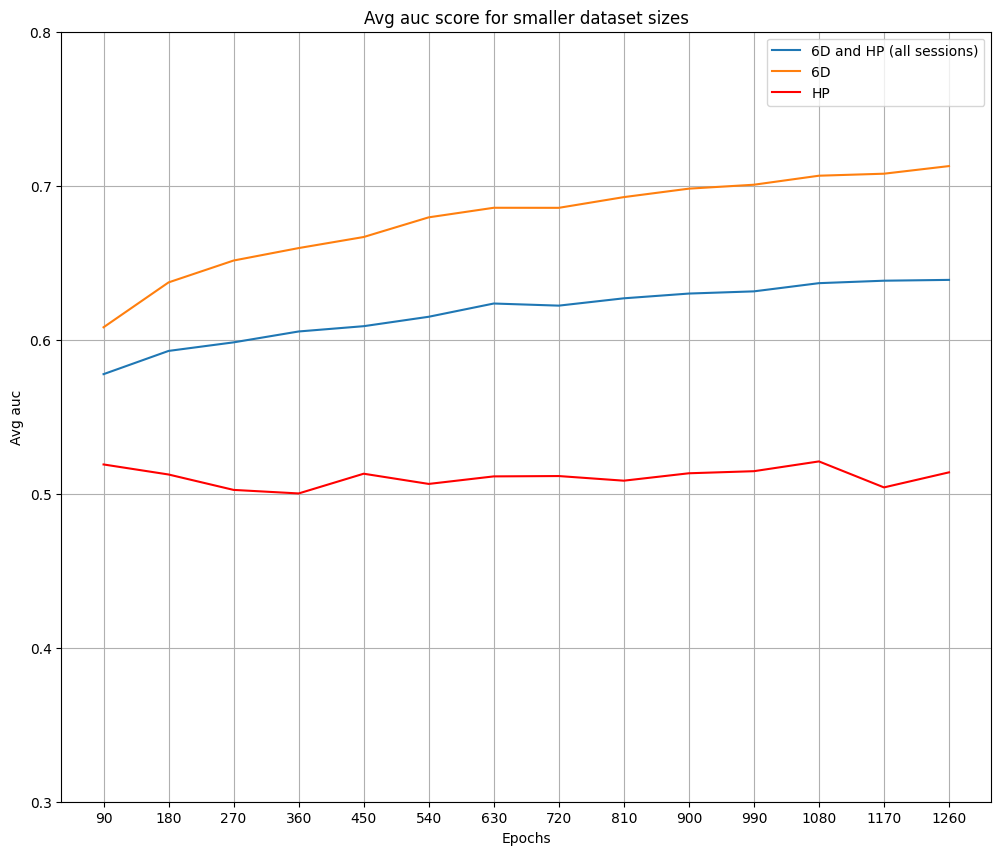

In [91]:
plt.figure(figsize=(12,10))
plt.plot(small_sizes, small_sizes_scores_all[0], label="6D and HP (all sessions)")
plt.plot(small_sizes, small_sizes_scores_6D[0], label="6D", color="tab:orange")
plt.plot(small_sizes, small_sizes_scores_HP[0], label="HP", color="red")
plt.title("Avg auc score for smaller dataset sizes")
plt.ylabel("Avg auc")
plt.xlabel("Epochs")
plt.xticks(small_sizes)
plt.grid()
plt.legend()
plt.ylim(0.3,0.8)
plt.show()

In [30]:
print(sizes_scores[1])

[264. 263. 263. 263. 262. 262. 262. 261. 261. 261. 260. 260. 260. 259.
 259. 259. 258. 258. 258. 257. 257. 257. 256. 256. 256. 255. 255. 255.
 254. 254. 254. 253. 253. 253. 252. 252. 252.]


In [30]:
print(sizes)
print(sizes_scores[1])
print(sizes_scores[0])

[ 1200  1800  2400  3000  3600  4200  4800  5400  6000  6600  7200  7800
  8400  9000  9600 10200 10800 11400 12000 12600 13200 13800 14400]
[79. 52. 39. 31. 26. 22. 19. 17. 15. 14. 13. 12. 11. 10.  9.  9.  8.  8.
  7.  7.  7.  6.  6.]
[0.63750734 0.65266598 0.65349051 0.6575905  0.66134632 0.66151733
 0.66313454 0.6606364  0.66373925 0.65624264 0.65307038 0.65618371
 0.65229547 0.65425284 0.65619149 0.65164946 0.6532929  0.64708017
 0.65396031 0.64873547 0.64296092 0.64680965 0.63421   ]


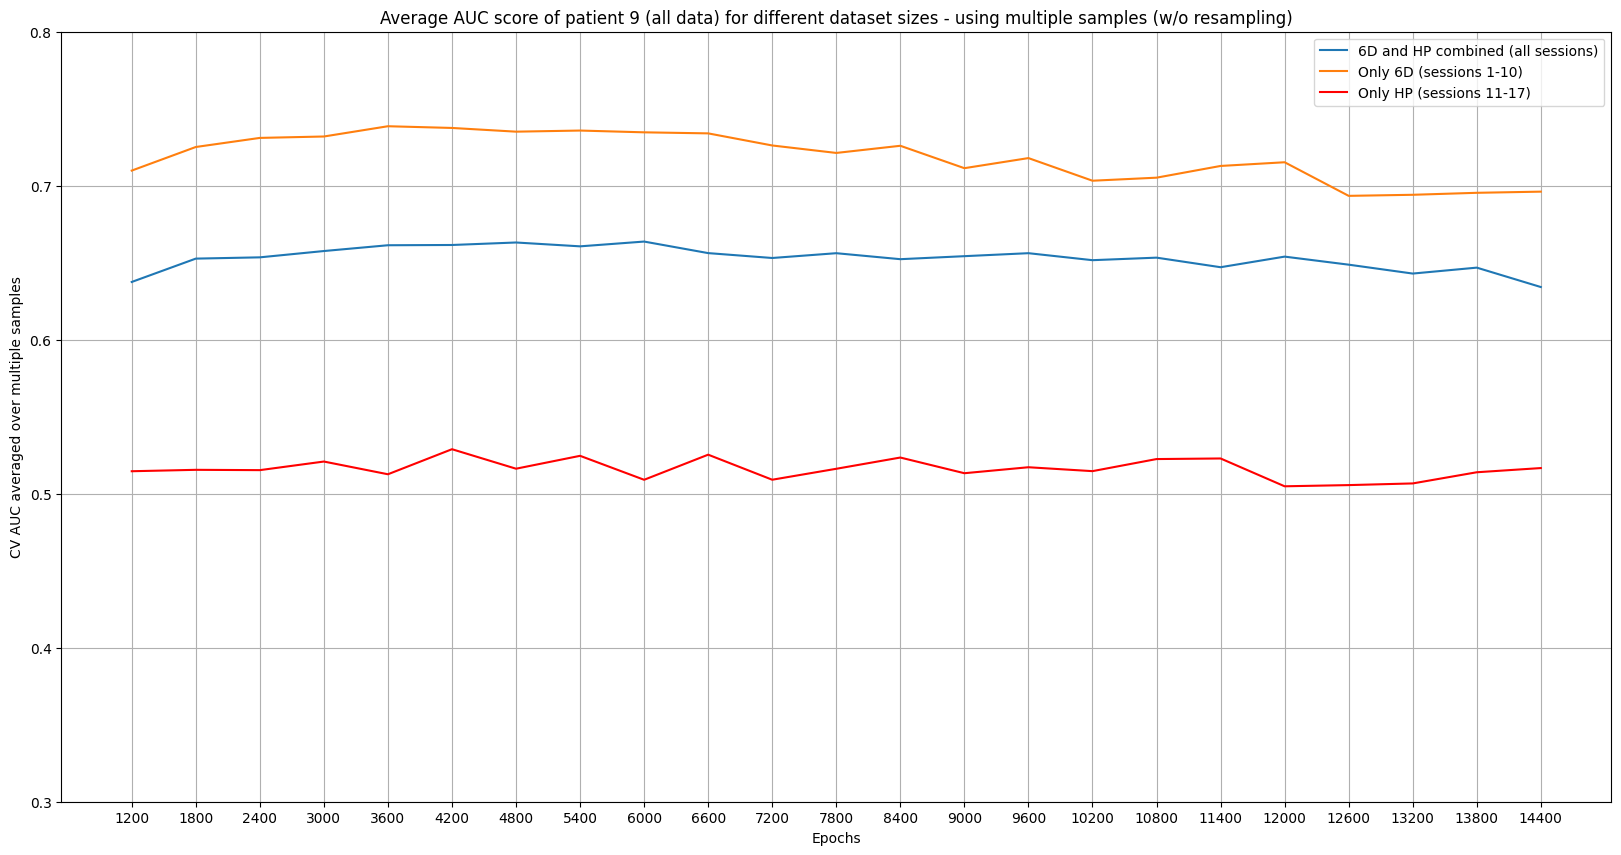

In [63]:
plt.figure(figsize=(20,10))
#plt.plot(small_sizes, small_sizes_scores_HP[0], color="red")
plt.plot(big_sizes, sizes_scores[0], label="6D and HP combined (all sessions)")
plt.plot(big_sizes, sizes_scores_6D[0], label="Only 6D (sessions 1-10)")
plt.plot(big_sizes, sizes_scores_HP[0], label="Only HP (sessions 11-17)", color="red")

#plt.xticks(sizes)
plt.grid()
plt.ylim(0.3,0.8)
plt.ylabel("CV AUC averaged over multiple samples")
plt.xlabel("Epochs")
plt.legend()
plt.xticks(big_sizes)
plt.title("Average AUC score of patient 9 (all data) for different dataset sizes - using multiple samples (w/o resampling)")
plt.show()


In [ ]:
sizes = np.arange(1200,15000,600)
step_size = 90
#sizes_scores = cv_auc_repeating_sizes(data_merged, sizes=sizes, step_size=step_size, tracker=True, resampling=False)
single_sizes_scores = cv_auc_single_sizes(data_merged, sizes=sizes, tracker=True)



Number of sizes: 23
Sizes: [ 1200  1800  2400  3000  3600  4200  4800  5400  6000  6600  7200  7800
  8400  9000  9600 10200 10800 11400 12000 12600 13200 13800 14400]
Trials total: 1302
Epochs total: 23760
Time intervals: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
Computing average auc score for size 1200
	 interval: [900,2100] / 23760
avg auc score: btlda 0.55034
Computing average auc score for size 1800
	 interval: [900,2700] / 23760
avg auc score: btlda 0.5436177777777778
Computing average auc score for size 2400
	 interval: [900,3300] / 23760
avg auc score: btlda 0.53747
Computing average auc score for size 3000
	 interval: [900,3900] / 23760
avg auc score: btlda 0.5507424000000001
Computing average auc score for size 3600
	 interval: [900,4500] / 23760
avg auc score: btlda 0.5555866666666667
Computing average auc score for size 4200
	 interval: [900,5100] / 23760
avg auc score: btlda 0.5531216326530611
Computing average auc score for size 4800
	 interval: [900,5700] / 23760
a

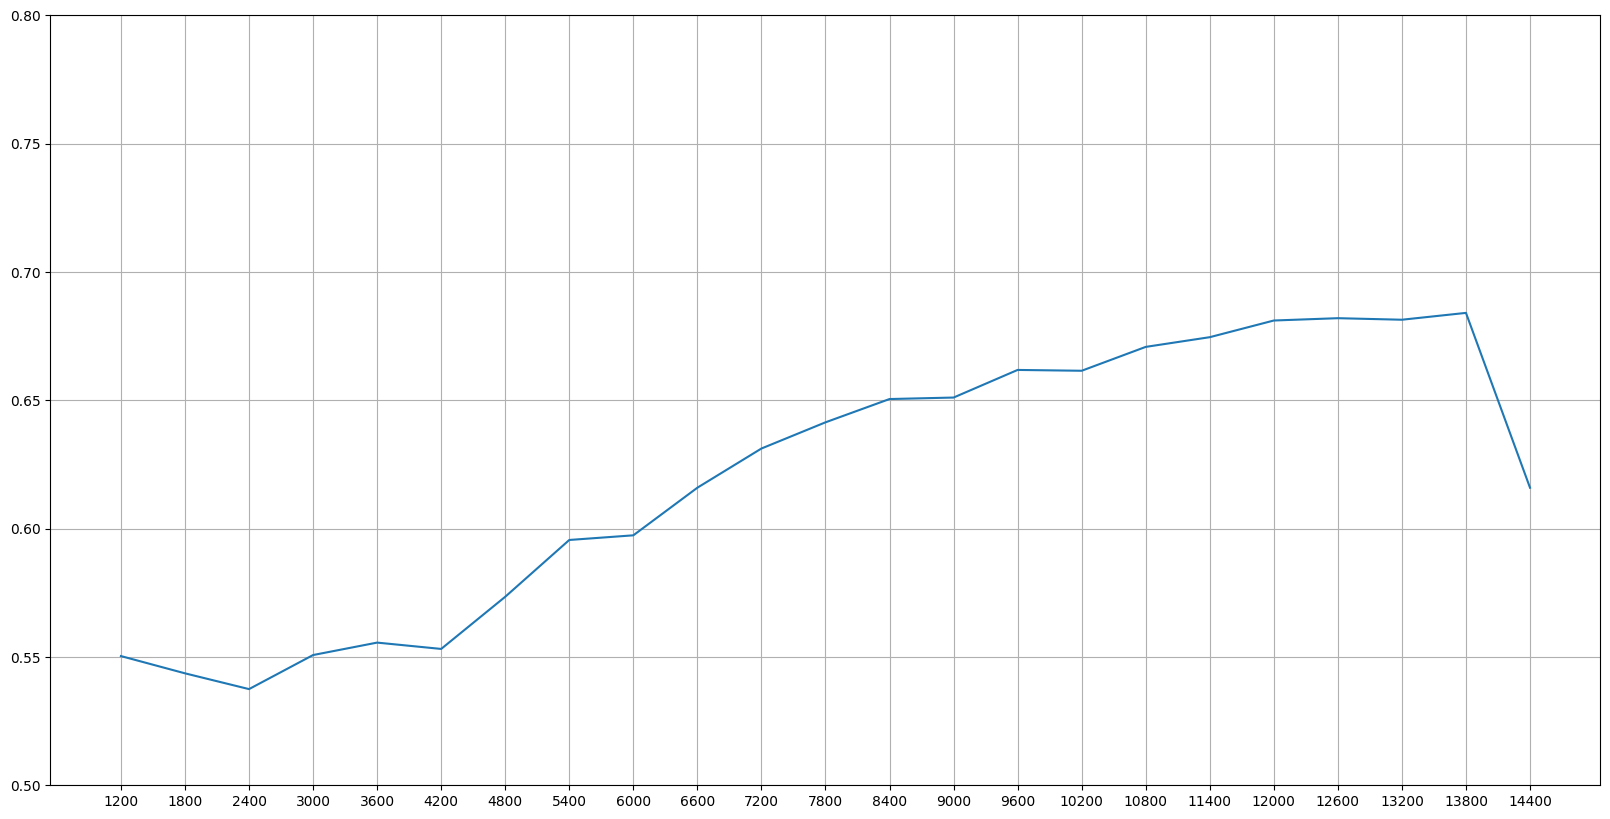

In [21]:
plt.figure(figsize=(20,10))
plt.plot(sizes, single_sizes_scores)
plt.xticks(sizes)
plt.grid()
plt.ylim(0.5,0.8)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

def auc_repeating_sizes(data, sizes = np.arange(90,900,90), step_size = 90, tracker=False, resampling=False):
    """ 
    This function computes the AUC scores for the classifiers sLDA and BTLDA over a set of different dataset sizes.

    The function keeps track of the AUC scores for different dataset sizes per classifier. For each dataset size, multiple samples (repetitions) are taken from the dataset, with a distance step_size between samples. Per dataset size, the number of taken samples is stored in repeats. The average over all samples is computed and its result is the final AUC score for that dataset size.

    Example for dataset size = 50, step_size = 10:
        sample 1 takes interval [50-100]
        sample 2 takes interval [60-110]
        sample 3 takes interval [70-120]
        etc.

    Input:
    - data (dict): obtained from merge_data(...)
    - sizes: np array of dataset sizes for which to compute the AUC score per classifier
    - step_size (int): size of steps to take between samples/repetitions. A low step_size gives a more reliable result, but takes very long to run!
    - tracker: True if you want to follow the process through implemented printing commands. False if you want to disable printing. 

    Output:
    - scores_w: matrix of size (sessions, conditions, sizes) with the AUC scores for sLDA. 
    - scores_bt: matrix of size (sessions, conditions, sizes) with the AUC scores for BT-LDA. 
    - repeats: np array that keeps track of the number of samples/repetitions for each data set size (taken from `sizes`)

    """
    all_trials = data.get('trials')
    #n_epochs = int(len(data.get('epochs'))/4) # for splitting it into 4 parts
    n_epochs = len(data.get('epochs'))
    scores_bt = np.zeros(sizes.size)  # btlda

    print(f"Number of sizes: {(scores_bt).shape[0]}")
    print(f"Sizes: {sizes}")
    print(f"Step size: {step_size}")
    print(f"Trials total: {len(all_trials)}")
    print(f"Epochs total: {n_epochs}")

    # added to keep track of the repetitions per dataset size 
    # the values differ per size, depending on how often the size fits in the full dataset
    repeats = np.array([])

    # Extract features (channel-prime)
    ival_bounds = np.arange(0.1,0.51,0.05)
    print(f"Time intervals: {ival_bounds}")
    X,y = epoch_vectorizer_channelprime(all_trials, ival_bounds=ival_bounds)

    # Initialize the classifier
    nch = (all_trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )

    jump_start = 0 # 0 for v1, 1 for v2, 2 for v3, 3 for v4. It means whether to take interval 0-n_epochs/4, or n_epochs/4 - 2*n_epochs/4, etc.

    for i, size in enumerate(sizes):
        size_scores = np.array([]) # btlda
        if resampling is False:
            step_size = size

        if tracker:
            print(f"Computing average auc score for size {size} (out of {(scores_bt).shape[0]})")

        # Repeating: loop over all possible intervals starting from the size itself, taking steps of the given step size
        for j in range(jump_start*n_epochs,jump_start*n_epochs + n_epochs-size+1,step_size):
            if tracker:
                #print(f"Total epoch range: [{n_epochs} - {2*n_epochs-size+1}]")
                print(f"\t interval: [{j},{j+size}] / {jump_start*n_epochs + n_epochs}")

            #print(y[0:j+size])
            size_scores = np.append(size_scores,roc(clf_btlda, X[0:j+size, :], y[0:j+size], cv=4, scoring='roc_auc').mean())

        # average the auc score over all repetitions to obtain the value for a certain dataset size
        scores_bt[i] = size_scores.mean() # btlda

        # Keeping track of the number of repetitions per dataset size
        # keep track only for session 1, condition 1. Otherwise we have 6 times the same repeats array
        repeats = np.append(repeats,len(size_scores))
            
        if tracker:
            #print("avg auc scores: lda {} - slda {} - btlda {}".format(m1.mean(), m2.mean(), m3.mean()))
            print(f"avg auc score: btlda {size_scores.mean()}")

    return scores_bt, repeats        

from sklearn.model_selection import cross_val_score

def auc_single_sizes(data, sizes = np.arange(90,900,90), tracker=False):

    all_trials = data.get('trials')
    n_epochs = int(len(data.get('epochs'))/4)
    scores_bt = np.zeros(sizes.size)  # btlda

    print(f"Number of sizes: {(scores_bt).shape[0]}")
    print(f"Sizes: {sizes}")
    print(f"Trials total: {len(all_trials)}")
    print(f"Epochs total: {n_epochs}")

    # added to keep track of the repetitions per dataset size 
    # the values differ per size, depending on how often the size fits in the full dataset
    repeats = np.array([])

    # Extract features (channel-prime)
    ival_bounds = np.arange(0.1,0.51,0.05)
    print(f"Time intervals: {ival_bounds}")
    X,y = epoch_vectorizer_channelprime(all_trials, ival_bounds=ival_bounds)

    # Initialize the classifier
    nch = (all_trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )


    for i, size in enumerate(sizes):

        if tracker:
            print(f"Computing average auc score for size {size}")

        print(f"\t interval: [{900},{900+size}] / {n_epochs}")

            #print(y[0:j+size])
        size_scores = (cross_val_score(clf_btlda, X[900:900+size, :], y[900:900+size], cv=4, scoring='roc_auc').mean())

        # average the auc score over all repetitions to obtain the value for a certain dataset size
        scores_bt[i] = size_scores # btlda

        # Keeping track of the number of repetitions per dataset size
        # keep track only for session 1, condition 1. Otherwise we have 6 times the same repeats array
        #repeats = np.append(repeats,len(size_scores))
            
        if tracker:
            #print("avg auc scores: lda {} - slda {} - btlda {}".format(m1.mean(), m2.mean(), m3.mean()))
            print(f"avg auc score: btlda {size_scores}")

    return scores_bt       


